# Ejercicio Ridge, Lasso y ElasticNet
Para este ejercicio vas a trabajar con datos de ventas de una empresa que fabrica muebles en España. Esta empresa es una Pyme que demanda conocer de antemano qué ingresos va a tener cada mes, ya que necesita pedir un anticipio a su entidad financiera de cara a poder abastecerse de materia prima al comenzar el mes. Como desconoce cuánto tiene que pedir, tira al alza y acaba pagando muchos intereses. El objetivo es reducir estos gastos.

En las bases de datos de la empresa constan todos los gastos en publicidad y ventas, para cada uno de los meses desde su fundación (hace más de 15 años).

Dado que los presupuestos de marketing se cierran al principio de cada mes, la empresa necesita un modelo predictivo que le anticipe las ventas que conseguirá a final de mes en función de los gastos que realizará en marketing.

Para ello tendrás que utilizar tanto modelos de regresión normales, como regularizados.

1. Carga los datos y realiza un pequeño análisis exploratorio. Mira a ver cómo se relaciona las ventas con el resto de variables.
2. Crea varios modelos y modifica los hiperparámetros necesarios para mejorar el performance del modelo.
3. Interpreta los resultados. Traduce a una fórmula tu mejor modelo (escribir la fórmula simplemente). ¿Cuánto cambian las ventas si aumentamos la inversión en radio un punto más? ¿Y si aumentamos la inversión en TV o periódicos?

## Import libraries 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Exploratory Data Analysis 

In [2]:
# Lectura datos, relación variables, mapas de correlación...

In [3]:
df = pd.read_csv('data/Advertising.csv')
df.head()

,Unnamed: 0,TV,radio,newpaper,sales
0,0,230.1,37.8,6s9.2,22100.0
1,1,44.5,39.3,45.1,10400.0
2,2,17.2,45.9,69.3,9300.0
3,3,151.5,41.3,58.5,18500.0
4,4,180.8,10.8,58.4,12900.0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   radio       200 non-null    float64
 3   newpaper    200 non-null    str    
 4   sales       200 non-null    float64
dtypes: float64(3), int64(1), str(1)
memory usage: 7.9 KB


Vemos que newpaper tiene tipo str. El primer registro contiene un error, hay más?

In [5]:
pd.to_numeric(df['newpaper'], errors='coerce').isna().sum()

np.int64(1)

Solo hay uno, es el primer registro, lo corregimos

In [6]:
df['newpaper'] = df['newpaper'].str.replace("s", "")
df['newpaper'] = df['newpaper'].astype(float)
df.rename(columns={"newpaper":"newspaper"}, inplace=True)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   radio       200 non-null    float64
 3   newspaper   200 non-null    float64
 4   sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [8]:
df.describe()

,Unnamed: 0,TV,radio,newspaper,sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,99.500000,147.042500,23.264000,30.554000,14022.500000
std,57.879185,85.854236,14.846809,21.778621,5217.456566
min,0.000000,0.700000,0.000000,0.300000,1600.000000
25%,49.750000,74.375000,9.975000,12.750000,10375.000000
50%,99.500000,149.750000,22.900000,25.750000,12900.000000
75%,149.250000,218.825000,36.525000,45.100000,17400.000000
max,199.000000,296.400000,49.600000,114.000000,27000.000000


Mapas de correlación

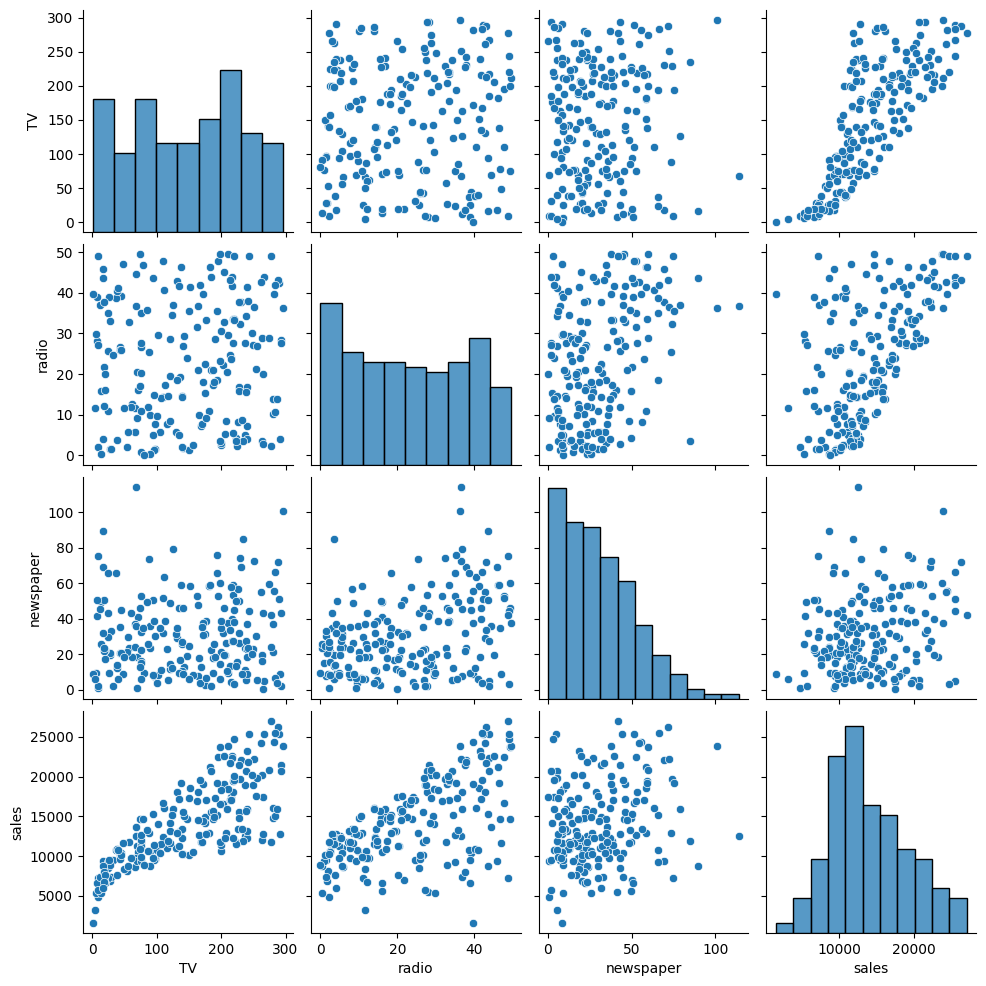

In [9]:
sns.pairplot(df.drop(columns='Unnamed: 0'));

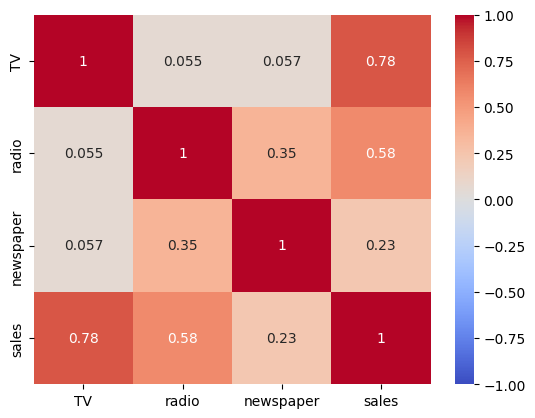

In [10]:
sns.heatmap(df.drop(columns='Unnamed: 0').corr(), annot=True, vmin=-1, vmax=1, cmap="coolwarm");

## Modelado

In [11]:
# Manipulación datasets, entrenamiento, evaluación, nuevas iteraciones... Prueba modelos sin y con regularización.

In [12]:
X = df[["TV", "radio", "newspaper"]]
y = df['sales']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(160, 3)
(40, 3)
(160,)
(40,)


### Regresión Lineal

In [13]:
lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)
baseline_error = mean_squared_error(y_test, y_pred)


print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("r2_score train", lr.score(X_train, y_train))
print("r2_score test",lr.score(X_test, y_test))

MAE: 1460.7567168117598
MSE: 3174097.3539761035
RMSE: 1781.59966153345
r2_score train 0.8957008271017817
r2_score test 0.899438024100912


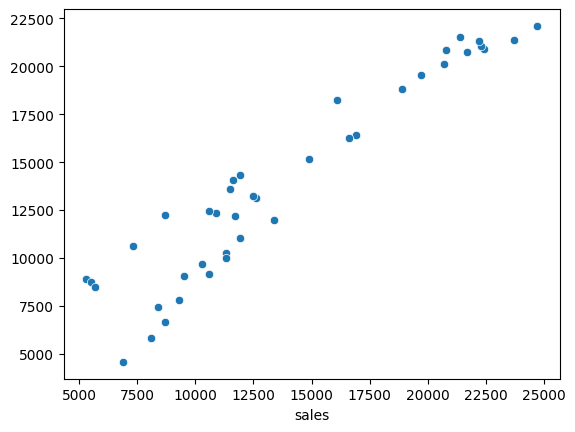

In [14]:
sns.scatterplot(x = y_test, y = y_pred);

RIDGE

In [15]:
from sklearn.linear_model import Ridge

ridgeR = Ridge(alpha = 0.5)
ridgeR.fit(X_train, y_train)

print("Train MSE sin regularización:", round(mean_squared_error(y_train, lr.predict(X_train)),2))
print("Test MSE sin regularización:", round(mean_squared_error(y_test, lr.predict(X_test)),2))

print("Train MSE con regularización:", round(mean_squared_error(y_train, ridgeR.predict(X_train)),2))
print("Test MSE con regularización:", round(mean_squared_error(y_test, ridgeR.predict(X_test)),2))

Train MSE sin regularización: 2705129.42
Test MSE sin regularización: 3174097.35
Train MSE con regularización: 2705129.42
Test MSE con regularización: 3174096.08


In [16]:
n_alphas = 100
alphas = np.logspace(1, 3, n_alphas) # por defecto es sobre base 10

coef_ridge = []
err_ridge = []
baseline = []

for a in alphas:
    ridge = Ridge(alpha=a) # probamos todas las alphas
    ridge.fit(X_train, y_train)
    
    coef_ridge.append(ridge.coef_)
    
    y_pred = ridge.predict(X_test)
    ridge_error = mean_squared_error(y_pred, y_test) # MSE de todos los predictores
    
    err_ridge.append(ridge_error)
    baseline.append(baseline_error)

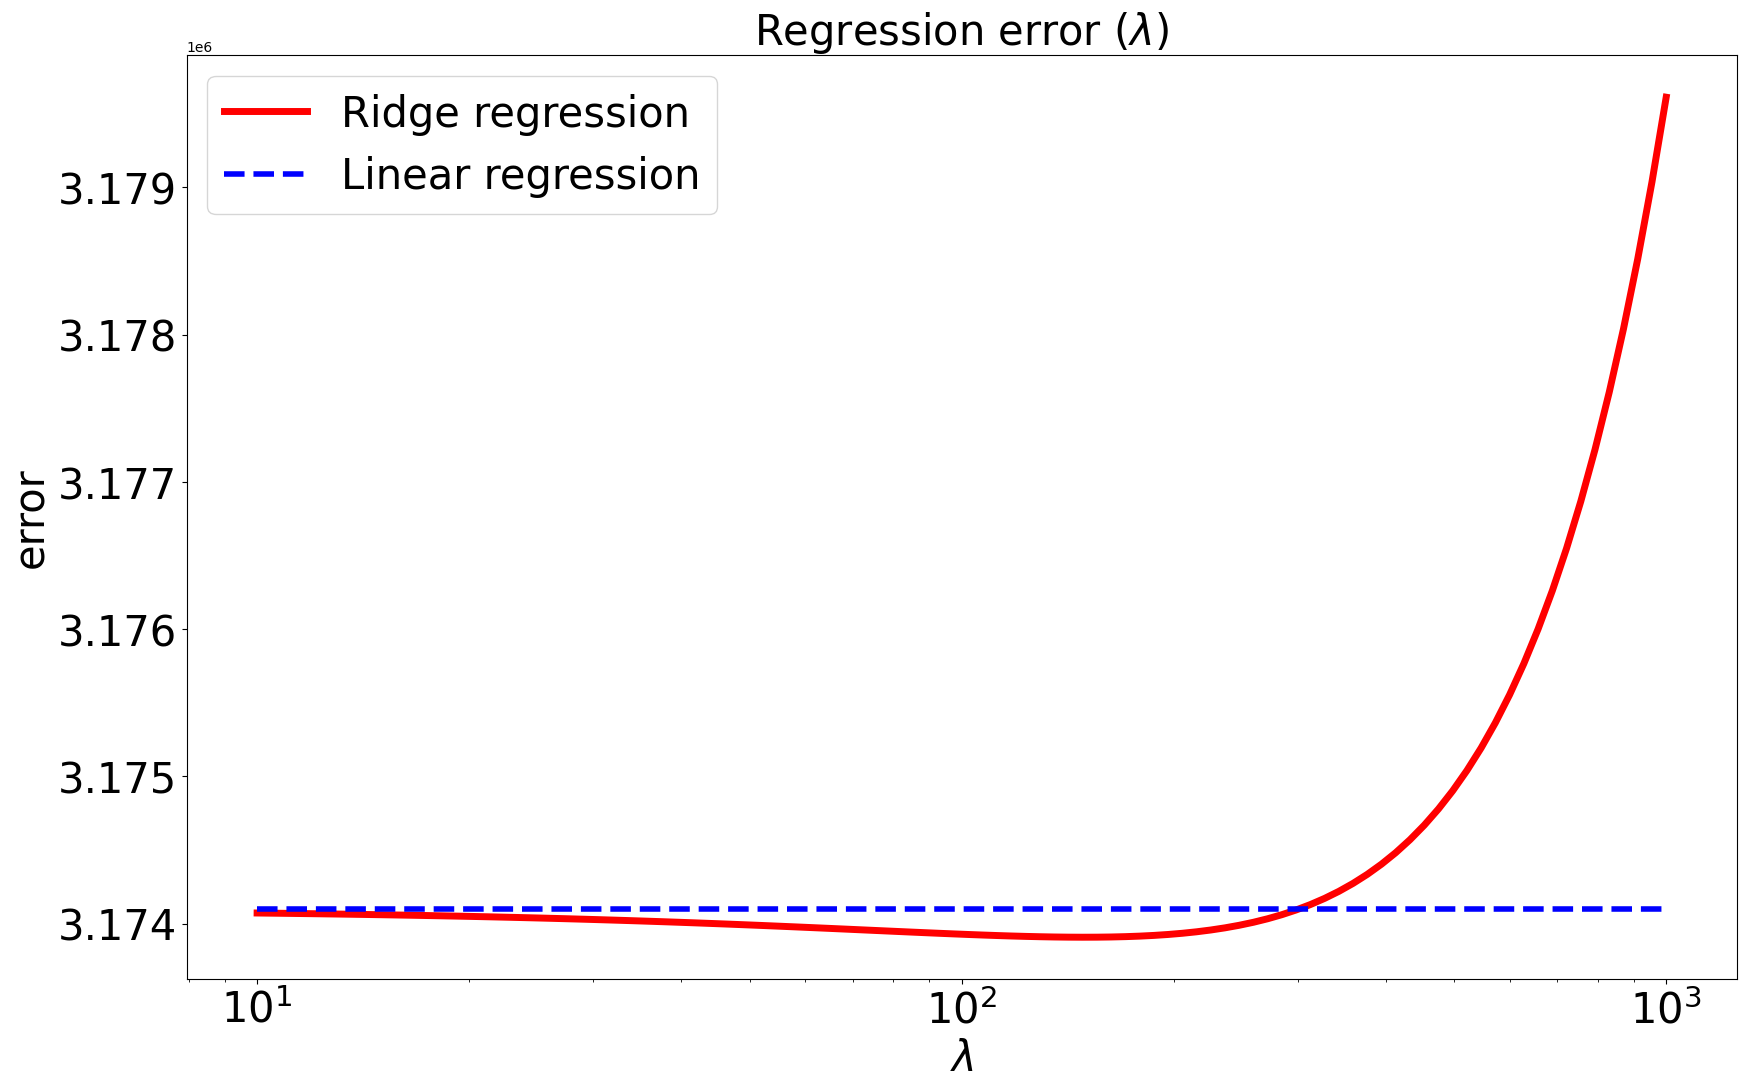

In [17]:
plt.figure(figsize=(20,12))
ax = plt.gca()
ax.plot(alphas, err_ridge, linewidth=5, color='red', label="Ridge regression")
ax.plot(alphas, baseline, linewidth=4,linestyle='--', color='blue', label='Linear regression')
ax.set_xscale('log')
plt.xlabel(r'$\lambda$', fontsize=30)
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
plt.ylabel('error', fontsize=30)
ax.legend(fontsize=30)
plt.title(r'Regression error ($\lambda$)', fontsize=30)
plt.show()

Mínimo se encuentra sobre los 300, aunque la diferencia es muy pequeña, no va a influir en mucho. Comprobamos

In [18]:
from sklearn.linear_model import Ridge 
  
# Train the model  
ridgeR = Ridge(alpha = 150)
ridgeR.fit(X_train, y_train) 

print("Train MSE: %0.4f" % mean_squared_error(y_train, ridgeR.predict(X_train)))
print("Test MSE: %0.4f" % mean_squared_error(y_test, ridgeR.predict(X_test)))

Train MSE: 2705296.2769
Test MSE: 3173908.2834


Nos da lo mismo, Ridge no nos ayuda a mejorar el modelo

LASSO

In [19]:
from sklearn.linear_model import Lasso

lassoR = Lasso(alpha=0.1)
lassoR.fit(X_train, y_train)

print("Train MSE sin regularización:", round(mean_squared_error(y_train, lr.predict(X_train)),2))
print("Test MSE sin regularización:", round(mean_squared_error(y_test, lr.predict(X_test)),2))

print("Train MSE: %0.4f" % mean_squared_error(y_train, lassoR.predict(X_train)))
print("Test MSE: %0.4f" % mean_squared_error(y_test, lassoR.predict(X_test)))

Train MSE sin regularización: 2705129.42
Test MSE sin regularización: 3174097.35
Train MSE: 2705129.4231
Test MSE: 3174093.7265


In [20]:
lasso = Lasso(fit_intercept=False)

n_alphas = 100
alphas = np.logspace(-1, 4, n_alphas) 

coef_lasso = []
err_lasso = []

for a in alphas:
    lasso.set_params(alpha=a)
    lasso.fit(X_train, y_train)
    coef_lasso.append(lasso.coef_)
    y_pred = lasso.predict(X_test)
    lasso_error = mean_squared_error(y_pred, y_test)    
    err_lasso.append(lasso_error)

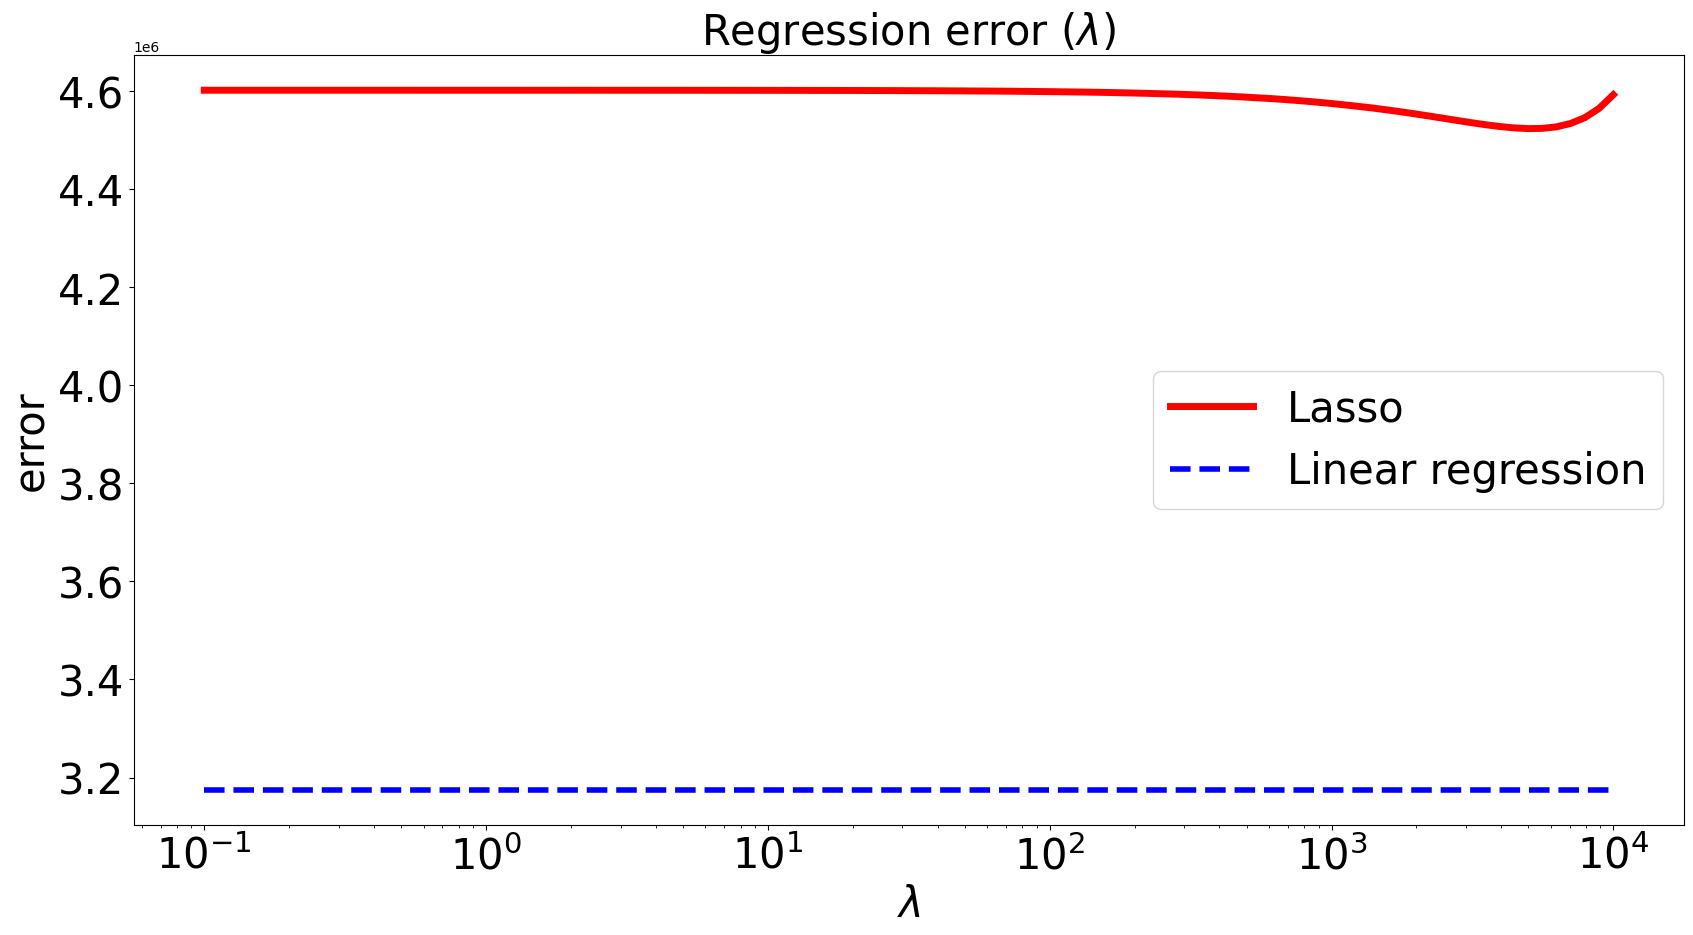

In [21]:
plt.figure(figsize=(20,10))
ax = plt.gca()
ax.plot(alphas, err_lasso, linewidth=5, color='red', label="Lasso")
ax.plot(alphas, baseline, linewidth=4,linestyle='--', color='blue', label='Linear regression')
ax.set_xscale('log')
plt.xlabel(r'$\lambda$', fontsize=30)
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
plt.ylabel('error', fontsize=30)
ax.legend(fontsize=30)
plt.title(r'Regression error ($\lambda$)', fontsize=30)
plt.show()

In [22]:
lassoR = Lasso(alpha = 1500) 
lassoR.fit(X_train, y_train) 

print("Train MSE: %0.4f" % mean_squared_error(y_train, lassoR.predict(X_train)))
print("Test MSE: %0.4f" % mean_squared_error(y_test, lassoR.predict(X_test)))

Train MSE: 2717016.4505
Test MSE: 3132955.8129


El mínimo para test y para train son diferentes, he intentado buscar un intermedio sobre los 1500.

ELASTIC NET

In [23]:
from sklearn.linear_model import ElasticNet

coef_eln = []
err_eln = []
baseline = []
for a in alphas: # alphas es el espacio definido antes (10^-4, 10^3)
    elastic_net = ElasticNet(alpha = a, l1_ratio=0.5) # lo mismo de ridge y lasso
    elastic_net.fit(X_train, y_train)
    coef_eln.append(elastic_net.coef_)
    y_pred = elastic_net.predict(X_test)
    elasticnet_error = mean_squared_error(y_pred, y_test)
    err_eln.append(elasticnet_error)
    baseline.append(baseline_error)

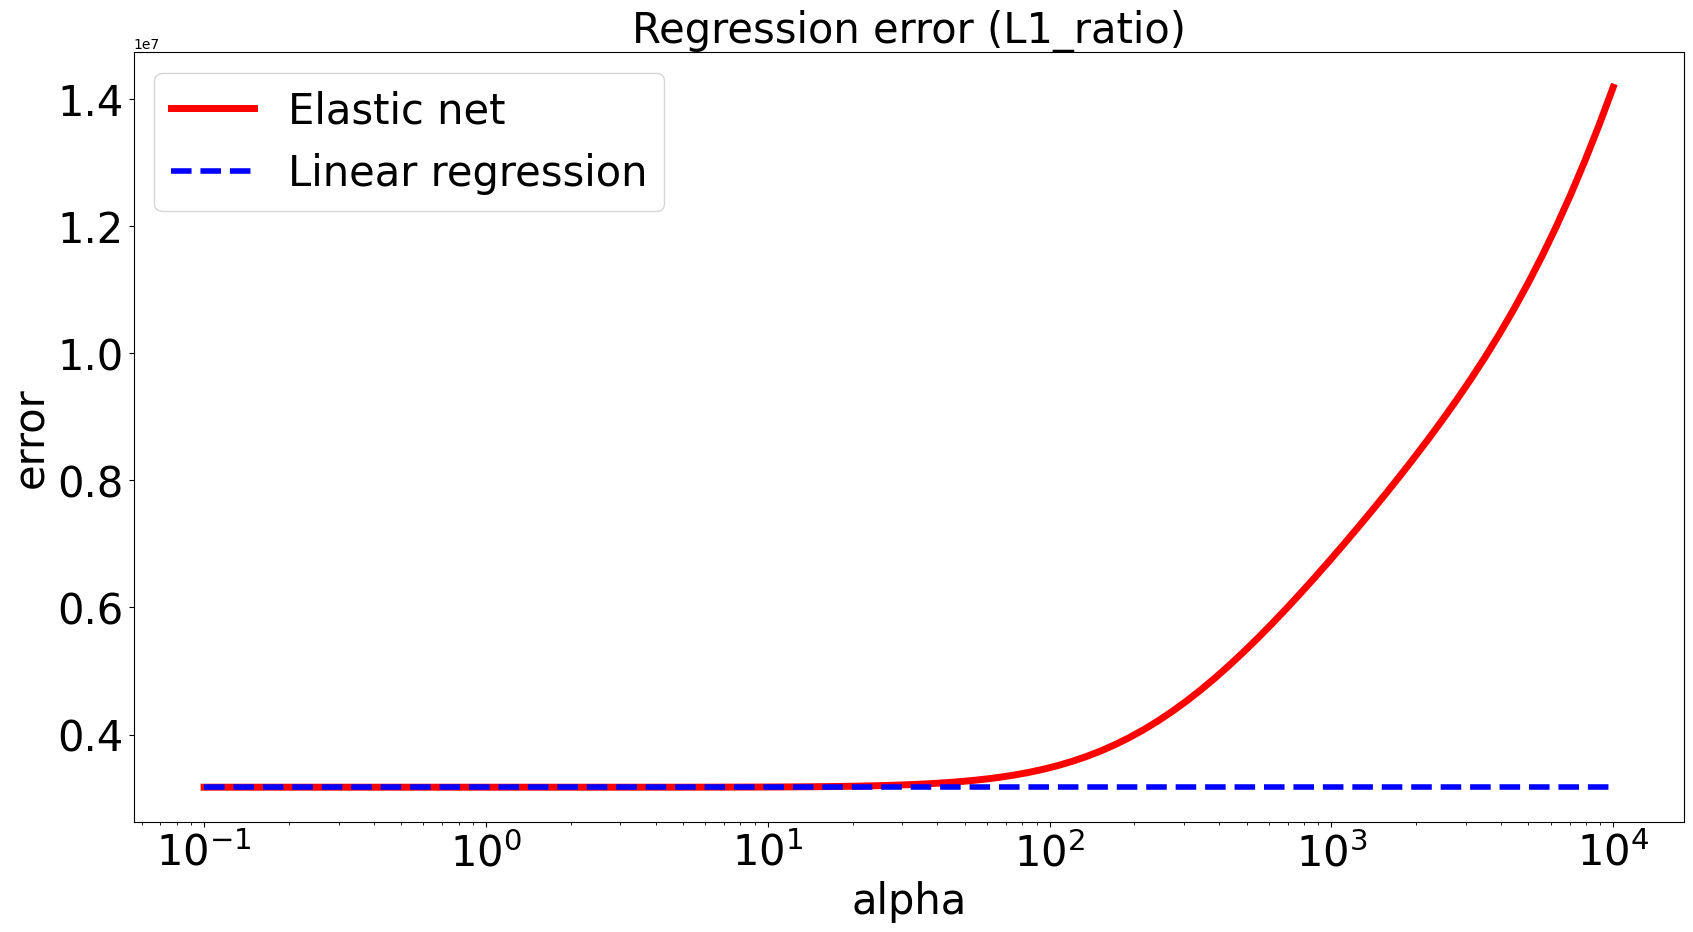

In [24]:
plt.figure(figsize=(20,10))
ax = plt.gca()
ax.plot(alphas, err_eln, linewidth=5, color='red', label="Elastic net")
ax.plot(alphas, baseline, linewidth=4,linestyle='--', color='blue', label='Linear regression')
ax.set_xscale('log')
plt.xlabel('alpha', fontsize=30)
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
plt.ylabel('error', fontsize=30)
ax.legend(fontsize=30)
plt.title(r'Regression error (L1_ratio)', fontsize=30)
plt.show()

Este modelo no va a mejorar nuestro modelo lineal

### Modelos Polinómicos

In [25]:
poly_feats = PolynomialFeatures(degree = 2)
poly_feats.fit(X)
X_poly = poly_feats.transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_poly,y, test_size = 0.2, random_state=42)

poly_reg = LinearRegression()
poly_reg.fit(X_train, y_train)

y_pred_ts = poly_reg.predict(X_test)
y_pred_tr = poly_reg.predict(X_train)

print("MAE:", mean_absolute_error(y_train, y_pred_tr))
print("MAE:", mean_absolute_error(y_test, y_pred_ts))
print("MSE:", mean_squared_error(y_train, y_pred_tr))
print("MSE:", mean_squared_error(y_test, y_pred_ts))
print("RMSE:", np.sqrt(mean_squared_error(y_train, y_pred_tr)))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_ts)))
print('R2 score train', r2_score(y_train, y_pred_tr))
print('R2 score test', r2_score(y_test, y_pred_ts))

MAE: 408.9721951355267
MAE: 526.1794444043974
MSE: 360396.674470122
MSE: 412910.22853791923
RMSE: 600.3304710491731
RMSE: 642.5809120553763
R2 score train 0.986104518792419
R2 score test 0.9869181490609599


Probamos con un polinomio de grado 3

In [26]:
poly_feats = PolynomialFeatures(degree = 3)
poly_feats.fit(X)
X_poly = poly_feats.transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_poly,y, test_size = 0.2, random_state=42)

poly_reg = LinearRegression()
poly_reg.fit(X_train, y_train)

y_pred_ts = poly_reg.predict(X_test)
y_pred_tr = poly_reg.predict(X_train)

print("MAE:", mean_absolute_error(y_train, y_pred_tr))
print("MAE:", mean_absolute_error(y_test, y_pred_ts))
print("MSE:", mean_squared_error(y_train, y_pred_tr))
print("MSE:", mean_squared_error(y_test, y_pred_ts))
print("RMSE:", np.sqrt(mean_squared_error(y_train, y_pred_tr)))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_ts)))
print('R2 score train', r2_score(y_train, y_pred_tr))
print('R2 score test', r2_score(y_test, y_pred_ts))

MAE: 317.70154192142144
MAE: 388.68170486224204
MSE: 216061.16397546837
MSE: 294568.40909603855
RMSE: 464.8237988479811
RMSE: 542.7415675033916
R2 score train 0.9916695295589968
R2 score test 0.9906674629185392


## Resultados

In [27]:
# Interpreta, resume y destaca los puntos importantes de los resultados.

Los modelos lineales no mejoran mucho los resultados iniciales

El mejor modelo lo obtenemos con los modelos polinómicos, tal vez sea overfitting. Con otro set de test más amplio podríamos confirmarlo.

In [28]:
# Utiliza todas las celdas que necesites...